In [ ]:
IMPORTS

In [1]:
import h5py
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)
print("All libraries loaded!")

TensorFlow version: 2.21.0
All libraries loaded!


In [ ]:
LOAD THE STEAD DATA

In [2]:
# Paths — adjust if your structure is different
NOISE_HDF5 = r'C:\Users\rajiv\OneDrive\Documents\VisualStudio\seismic_CNN\chunk1\chunk1.hdf5'
EQ_HDF5    = r'C:\Users\rajiv\OneDrive\Documents\VisualStudio\seismic_CNN\chunk2\chunk2.hdf5'
NOISE_CSV  = r'C:\Users\rajiv\OneDrive\Documents\VisualStudio\seismic_CNN\chunk1\chunk1.csv'
EQ_CSV     = r'C:\Users\rajiv\OneDrive\Documents\VisualStudio\seismic_CNN\chunk2\chunk2.csv'

WAVE_LENGTH = 6000   # STEAD waveforms = 6000 samples (60 sec at 100Hz)
N_EACH      = 1000   # 1000 noise + 1000 earthquake = 2000 total

def load_stead_samples(hdf5_path, csv_path, n_samples, label):
    X, y = [], []

    # Read CSV to get trace names
    df = pd.read_csv(csv_path)
    print(f"CSV loaded — {len(df)} total entries")

    # Sample n_samples rows
    df = df.sample(n=min(n_samples, len(df)), random_state=42)

    with h5py.File(hdf5_path, 'r') as f:
        for _, row in df.iterrows():
            try:
                trace_name = row['trace_name']
                waveform   = f['data'][trace_name][:]   # shape: (6000, 3)

                # Use vertical (Z) channel only — index 2
                channel = waveform[:, 2].astype(np.float32)

                # Normalize by standard deviation
                channel = channel / (np.std(channel) + 1e-8)

                X.append(channel)
                y.append(label)
            except Exception as e:
                continue   # skip corrupted entries silently

    print(f"Loaded {len(X)} samples with label={label}")
    return X, y

# Load both classes
print("Loading noise waveforms...")
X_noise, y_noise = load_stead_samples(NOISE_HDF5, NOISE_CSV, N_EACH, label=0)

print("\nLoading earthquake waveforms...")
X_eq, y_eq = load_stead_samples(EQ_HDF5, EQ_CSV, N_EACH, label=1)

# Combine
X = np.array(X_noise + X_eq)[..., np.newaxis]   # shape: (2000, 6000, 1)
y = np.array(y_noise + y_eq)

# Shuffle
idx  = np.random.permutation(len(X))
X, y = X[idx], y[idx]

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nFinal dataset:")
print(f"Input shape    : {X.shape}")
print(f"Earthquakes    : {np.sum(y==1)}")
print(f"Noise          : {np.sum(y==0)}")
print(f"Train          : {len(X_train)}")
print(f"Test           : {len(X_test)}")

Loading noise waveforms...
CSV loaded — 235426 total entries
Loaded 1000 samples with label=0

Loading earthquake waveforms...


C:\Users\rajiv\AppData\Local\Temp\ipykernel_50604\2445058192.py:14: DtypeWarning: Columns (26) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)


CSV loaded — 200000 total entries
Loaded 1000 samples with label=1

Final dataset:
Input shape    : (2000, 6000, 1)
Earthquakes    : 1000
Noise          : 1000
Train          : 1600
Test           : 400


In [ ]:
PLOT THE STEAD WAVEFORM

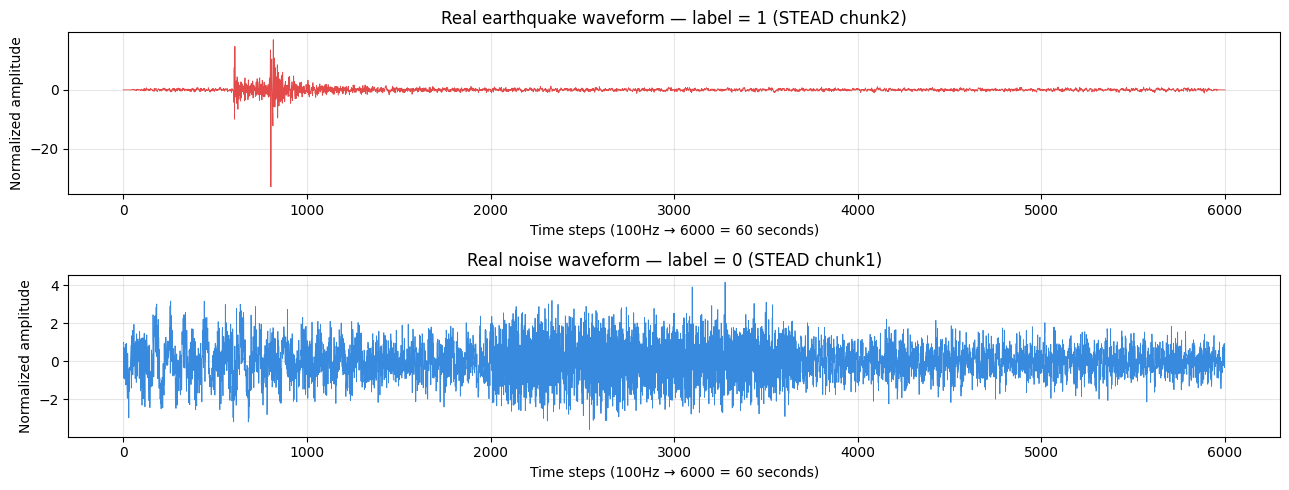

In [3]:
eq_idx    = np.where(y == 1)[0][0]
noise_idx = np.where(y == 0)[0][0]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 5))

ax1.plot(X[eq_idx, :, 0], color='#E24B4A', linewidth=0.6)
ax1.set_title('Real earthquake waveform — label = 1 (STEAD chunk2)')
ax1.set_xlabel('Time steps (100Hz → 6000 = 60 seconds)')
ax1.set_ylabel('Normalized amplitude')
ax1.grid(True, alpha=0.3)

ax2.plot(X[noise_idx, :, 0], color='#378ADD', linewidth=0.6)
ax2.set_title('Real noise waveform — label = 0 (STEAD chunk1)')
ax2.set_xlabel('Time steps (100Hz → 6000 = 60 seconds)')
ax2.set_ylabel('Normalized amplitude')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
CONFIRM SPLIT

In [4]:
print(f"Training samples : {len(X_train)}")
print(f"Test samples     : {len(X_test)}")
print(f"Input shape      : {X_train.shape}")

Training samples : 1600
Test samples     : 400
Input shape      : (1600, 6000, 1)


In [ ]:
BUILD CNN

In [5]:
model = models.Sequential([

    # CONVOLUTIONAL LAYER 1
    layers.Conv1D(32, kernel_size=5, activation='relu',
                  input_shape=(6000, 1)),
    layers.BatchNormalization(),
    layers.MaxPooling1D(pool_size=4),

    # CONVOLUTIONAL LAYER 2
    layers.Conv1D(64, kernel_size=3, activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling1D(pool_size=4),

    # CONVOLUTIONAL LAYER 3
    layers.Conv1D(128, kernel_size=3, activation='relu'),
    layers.MaxPooling1D(pool_size=4),

    # FLATTEN
    layers.Flatten(),

    # FULLY CONNECTED
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),

    # OUTPUT
    layers.Dense(1, activation='sigmoid')
])

model.summary()

C:\Users\rajiv\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                      │ (None, 5996, 32)            │             192 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 5996, 32)            │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d (MaxPooling1D)         │ (None, 1499, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_1 (Conv1D)                    │ (None, 1497, 64)            │           6,208 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 1497, 64)            │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_1 (MaxPooling1D)       │ (None, 374, 64)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_2 (Conv1D)                    │ (None, 372, 128)            │          24,704 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_2 (MaxPooling1D)       │ (None, 93, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 11904)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │         761,920 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 793,473 (3.03 MB)

 Trainable params: 793,281 (3.03 MB)

 Non-trainable params: 192 (768.00 B)

In [ ]:
COMPILE 

In [6]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
print("Model compiled!")

Model compiled!


In [ ]:
TRAIN 

In [7]:
# Learning rate scheduler — slows down when model stops improving
lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=64,        # 64 for faster training on CPU
    validation_split=0.1,
    callbacks=[lr_scheduler],
    verbose=1
)

Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 9s 194ms/step - accuracy: 0.8660 - loss: 0.6971 - val_accuracy: 0.9438 - val_loss: 0.2353 - learning_rate: 0.0010
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 170ms/step - accuracy: 0.9653 - loss: 0.1319 - val_accuracy: 0.9500 - val_loss: 0.3600 - learning_rate: 0.0010
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 169ms/step - accuracy: 0.9708 - loss: 0.1053 - val_accuracy: 0.9563 - val_loss: 0.3379 - learning_rate: 0.0010
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - accuracy: 0.9730 - loss: 0.0965
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 172ms/step - accuracy: 0.9806 - loss: 0.0805 - val_accuracy: 0.8750 - val_loss: 0.4347 - learning_rate: 0.0010
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 169ms/step - accuracy: 0.9854 - loss: 0.0551 - val_accuracy: 0.7937 - val_loss: 0.4737 - learning_rate: 5.0000e-04
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 172ms/step - accuracy: 0.9854 - loss: 0.0495

In [ ]:
PLOT CURVES

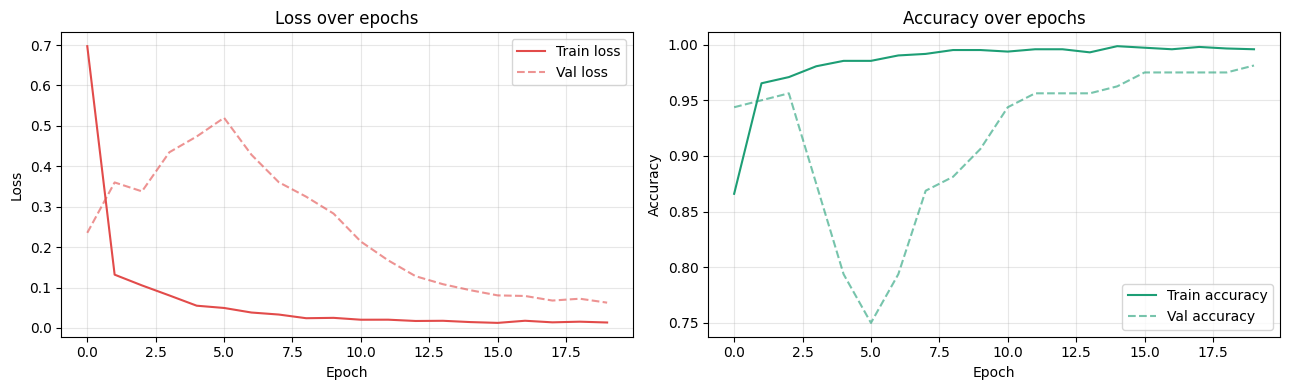

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(history.history['loss'],     label='Train loss',     color='#E24B4A')
ax1.plot(history.history['val_loss'], label='Val loss',       color='#E24B4A',
         linestyle='--', alpha=0.6)
ax1.set_title('Loss over epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history.history['accuracy'],     label='Train accuracy', color='#1D9E75')
ax2.plot(history.history['val_accuracy'], label='Val accuracy',   color='#1D9E75',
         linestyle='--', alpha=0.6)
ax2.set_title('Accuracy over epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
EVALUATE 

In [9]:
y_pred_prob = model.predict(X_test)
y_pred      = (y_pred_prob > 0.5).astype(int)

print("=== Classification Report ===")
print(classification_report(y_test, y_pred,
      target_names=['Noise', 'Earthquake']))

print("=== Confusion Matrix ===")
print(confusion_matrix(y_test, y_pred))

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step
=== Classification Report ===
              precision    recall  f1-score   support

       Noise       0.98      0.99      0.98       200
  Earthquake       0.99      0.97      0.98       200

    accuracy                           0.98       400
   macro avg       0.98      0.98      0.98       400
weighted avg       0.98      0.98      0.98       400

=== Confusion Matrix ===
[[198   2]
 [  5 195]]


In [ ]:
SINGLE PREDICTION 

In [28]:
print(f"Test set size: {len(X_test)} samples")
print(f"Valid indices: 0 to {len(X_test)-1}\n")

idx        = 300
sample     = X_test[idx : idx+1]
true_label = y_test[idx]

prob      = model.predict(sample, verbose=0)[0][0]
predicted = "Earthquake" if prob > 0.5 else "Noise"
actual    = "Earthquake" if true_label == 1 else "Noise"

print(f"Probability score : {prob:.4f}")
print(f"Predicted         : {predicted}")
print(f"Actual            : {actual}")
print(f"Correct?          : {'Yes' if predicted == actual else 'No'}")

Test set size: 400 samples
Valid indices: 0 to 399

Probability score : 0.0012
Predicted         : Noise
Actual            : Noise
Correct?          : Yes


In [18]:
# Count labels by position in test set
first_half  = y_test[:200]
second_half = y_test[200:]

print(f"Indices 0-199   → Noise: {np.sum(first_half==0)}, Earthquake: {np.sum(first_half==1)}")
print(f"Indices 200-399 → Noise: {np.sum(second_half==0)}, Earthquake: {np.sum(second_half==1)}")

Indices 0-199   → Noise: 103, Earthquake: 97
Indices 200-399 → Noise: 97, Earthquake: 103


In [25]:
for i in [0, 50, 100, 150, 200, 250, 300, 350, 399]:
    label = "Earthquake" if y_test[i] == 1 else "Noise"
    print(f"idx {i:3d} → actual label: {label}")

idx   0 → actual label: Noise
idx  50 → actual label: Earthquake
idx 100 → actual label: Noise
idx 150 → actual label: Noise
idx 200 → actual label: Earthquake
idx 250 → actual label: Earthquake
idx 300 → actual label: Noise
idx 350 → actual label: Noise
idx 399 → actual label: Earthquake


In [29]:
y_pred_prob = model.predict(X_test, verbose=0)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

wrong_indices = np.where(y_pred != y_test)[0]
print(f"Wrong predictions at indices: {wrong_indices}")

for i in wrong_indices:
    actual    = "Earthquake" if y_test[i] == 1 else "Noise"
    predicted = "Earthquake" if y_pred[i] == 1 else "Noise"
    score     = y_pred_prob[i][0]
    print(f"idx {i:3d} → actual: {actual:12s} predicted: {predicted:12s} score: {score:.4f}")

Wrong predictions at indices: [ 15  80  85 141 194 263 287]
idx  15 → actual: Noise        predicted: Earthquake   score: 0.5212
idx  80 → actual: Earthquake   predicted: Noise        score: 0.3546
idx  85 → actual: Earthquake   predicted: Noise        score: 0.0242
idx 141 → actual: Noise        predicted: Earthquake   score: 0.9989
idx 194 → actual: Earthquake   predicted: Noise        score: 0.2373
idx 263 → actual: Earthquake   predicted: Noise        score: 0.2269
idx 287 → actual: Earthquake   predicted: Noise        score: 0.0192


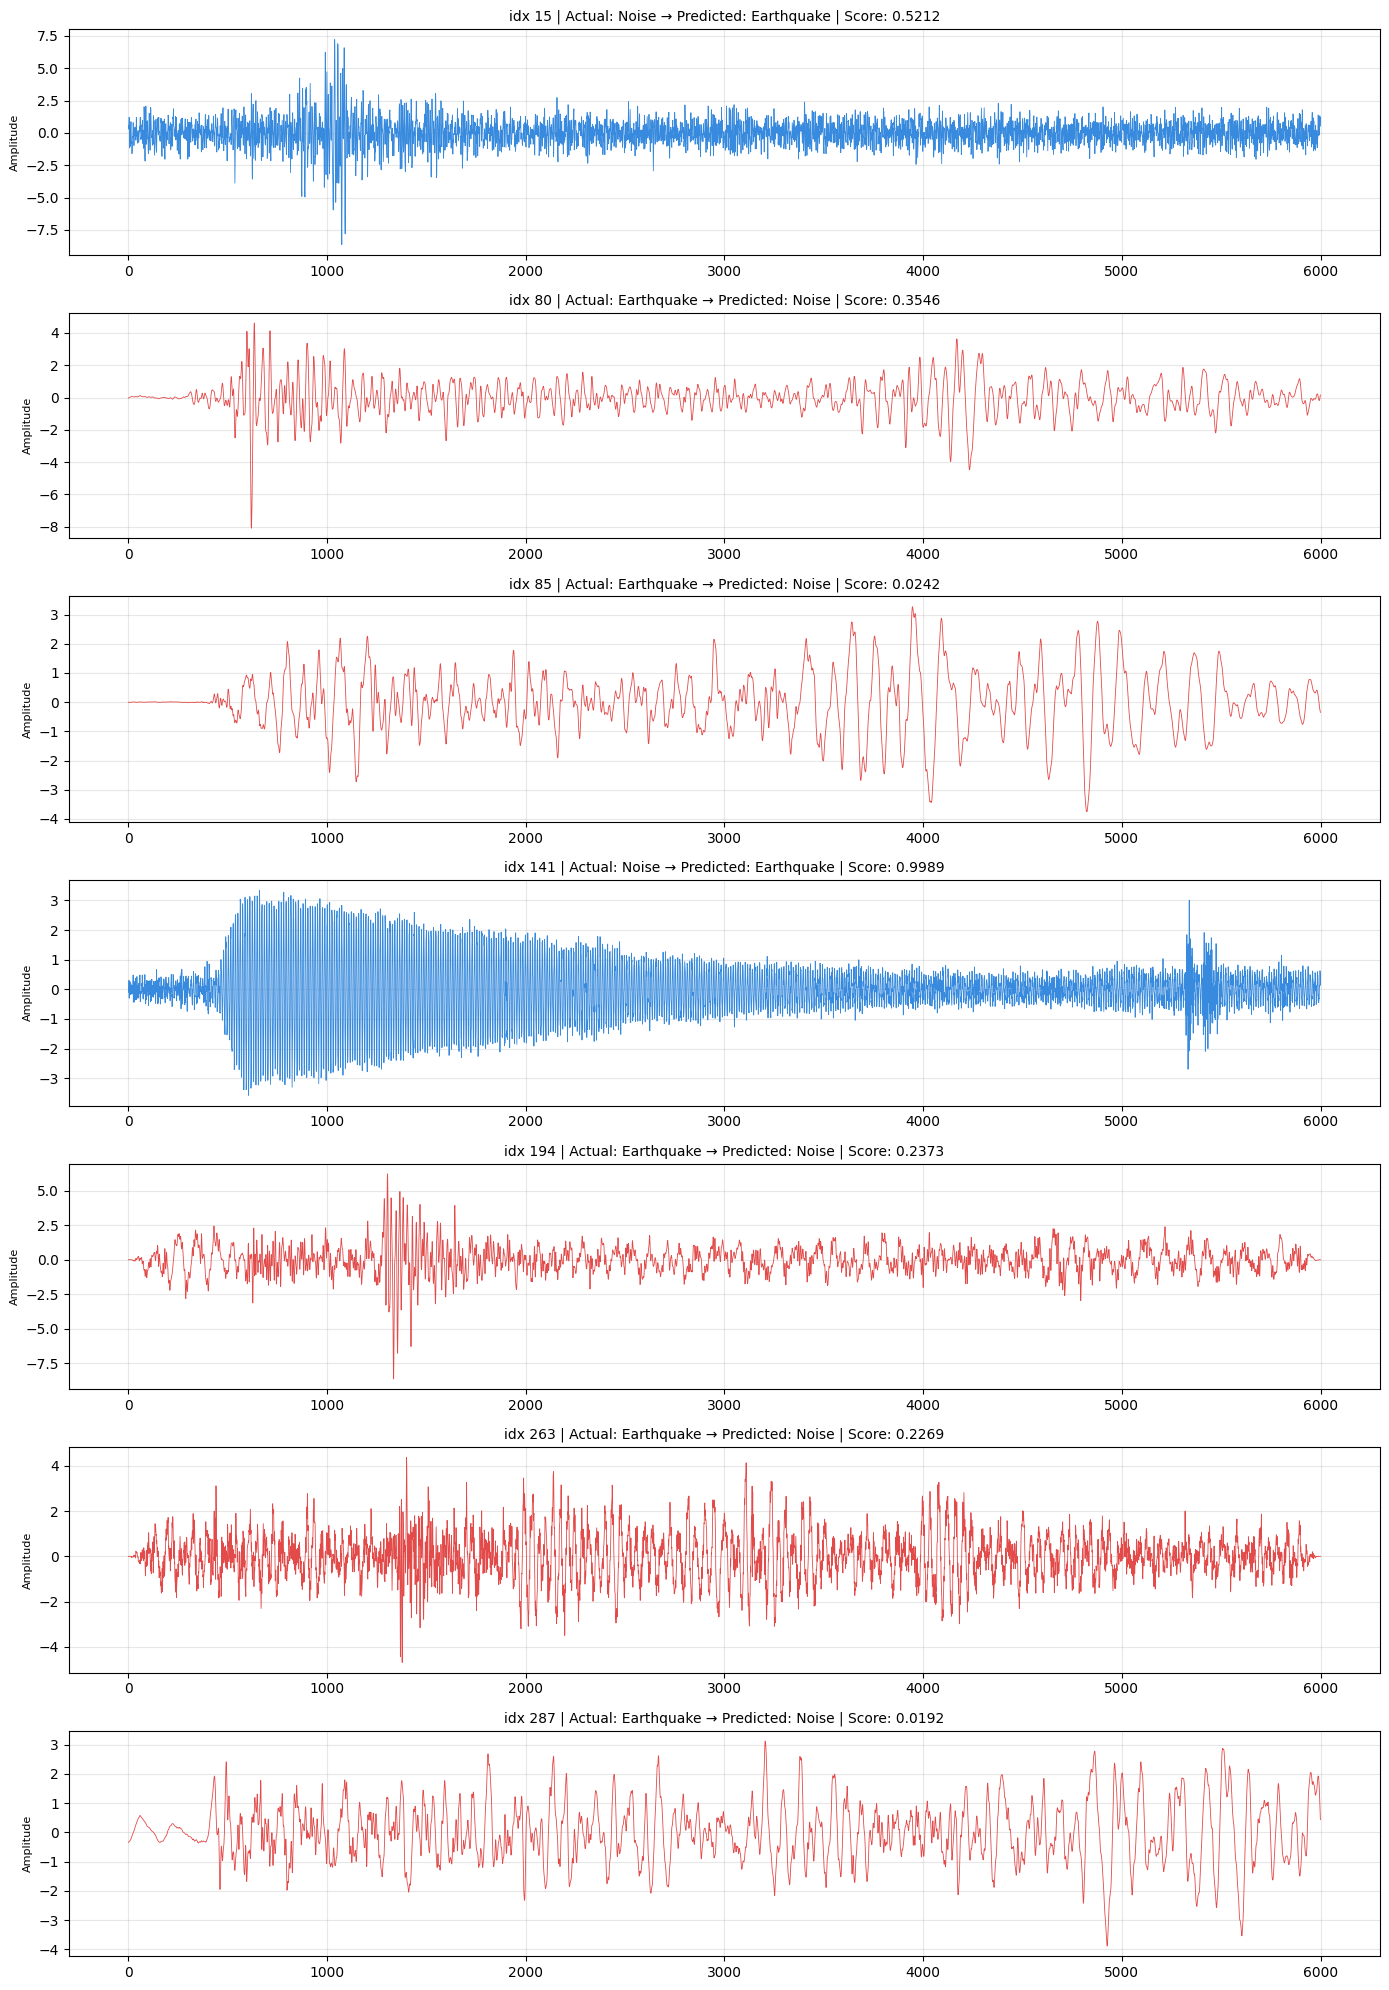

In [30]:
fig, axes = plt.subplots(7, 1, figsize=(14, 20))
wrong_indices = [15, 80, 85, 141, 194, 263, 287]

for ax, i in zip(axes, wrong_indices):
    actual    = "Earthquake" if y_test[i] == 1 else "Noise"
    predicted = "Earthquake" if y_pred[i] == 1 else "Noise"
    score     = y_pred_prob[i][0]
    color     = '#E24B4A' if y_test[i] == 1 else '#378ADD'

    ax.plot(X_test[i, :, 0], color=color, linewidth=0.6)
    ax.set_title(
        f'idx {i} | Actual: {actual} → Predicted: {predicted} | Score: {score:.4f}',
        fontsize=10
    )
    ax.set_ylabel('Amplitude', fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()